In [2]:
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import bayesflow as bf
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np

matplotlib.rcParams["figure.dpi"] = 72

/opt/anaconda3/envs/bayesflow/lib/python3.11/site-packages/bayesflow/trainers.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
def prior(D=1, alpha=2.0, beta=1.0):
    """Inverse Gamma prior random number generator using Gamma distribution."""
    return 1 / np.random.default_rng().gamma(shape=alpha, scale=1/beta, size=D)

def simulator(theta, n_obs=100, mean=0.0):
    """Gaussian likelihood random number generator."""
    return np.random.default_rng().normal(loc=mean, scale=np.sqrt(theta), size=(n_obs, theta.shape[0]))

generative_model = bf.simulation.GenerativeModel(
    prior=prior, simulator=simulator, name="Generative Model: Training", simulator_is_batched=False
)

INFO:root:Performing 2 pilot runs with the Generative Model: Training model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 100, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


In [4]:
summary_net = bf.networks.DeepSet(summary_dim=10)
inference_net = bf.networks.InvertibleNetwork(num_params=1, num_coupling_layers=2)
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net, summary_loss_fun="MMD")
trainer = bf.trainers.Trainer(generative_model=generative_model, amortizer=amortizer, memory=True)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [5]:
losses = trainer.train_online(epochs=15, iterations_per_epoch=500, batch_size=32)

Training epoch 15: 100%|██████████| 500/500 [00:07<00:00, 70.38it/s, Epoch: 15, Iter: 500,Loss: -0.077,W.Decay: 0.023,Avg.Loss: -0.083,Avg.W.Decay: 0.023,LR: 1.49E-11]


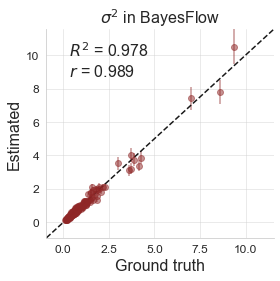

In [19]:
new_sims = trainer.configurator(trainer.generative_model(200))
posterior_draws = amortizer.sample(new_sims, n_samples=500)
fig = bf.diagnostics.plot_recovery(posterior_draws, new_sims["parameters"])


fig.axes[0].set_title(r"$\sigma^2$ in BayesFlow", fontsize=16)
plt.show()

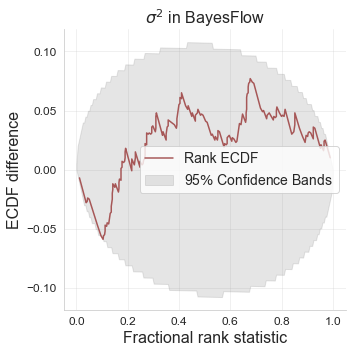

In [20]:
fig = bf.diagnostics.plot_sbc_ecdf(posterior_draws, new_sims["parameters"], difference=True)


fig.axes[0].set_title(r"$\sigma^2$ in BayesFlow", fontsize=16)
plt.show()

In [8]:

def bayes_estimator(Z,alpha_0=2.0, beta_0=1.0, n_samples=1000):
    """
    Implements a Bayesian estimator, calculates the posterior distribution 
    based on the prior and observed data, and samples from it.

    Parameters:
    - Z: Input data, expected shape (batch_size, n_obs, 1).
    - mu_0: Prior mean.
    - alpha_0: Initial shape parameter of the Inverse-Gamma distribution.
    - beta_0: Initial scale parameter of the Inverse-Gamma distribution.
    - n_samples: Number of posterior samples to draw.

    Returns:
    - posterior_samples: 1000 samples drawn from the posterior distribution.
    """
    # Convert Z to a TensorFlow tensor (ensure dtype is float32)
    Z = tf.convert_to_tensor(Z, dtype=tf.float32)

    # Compute the mean over the observation dimension (axis=1)
    y_bar = tf.reduce_mean(Z, axis=1, keepdims=True)  # Shape: (batch_size, 1, 1)
    n = tf.cast(tf.shape(Z)[1], tf.float32)  # Number of observations (n_obs), scalar

    # Compute the sum of squared differences from y_bar
    variance = tf.reduce_sum(tf.square(Z - y_bar), axis=1, keepdims=True)  # Shape: (batch_size, 1)

    # Update the posterior parameters for the Inverse-Gamma distribution
    alpha = alpha_0 + n / 2  # Shape: scalar
    beta = beta_0 + variance / 2  # Shape: (batch_size, 1)

    # Define the posterior distribution (Inverse-Gamma)
    dist = tfp.distributions.InverseGamma(concentration=alpha, scale=beta)

    # Sample from the posterior distribution
    posterior_samples = dist.sample(n_samples).numpy()  # Shape: (n_samples, batch_size, 1)

    return posterior_samples.squeeze()  # Remove unnecessary dimensions if any


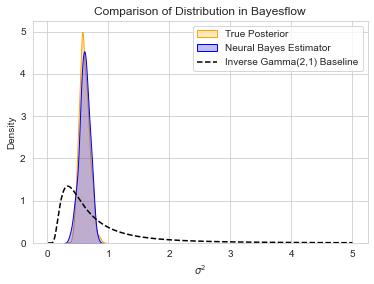

In [ ]:
n_obs = 100  # Number of samples
true_miu = 0  # True mean
true_sigma = 0.8  # True standard deviation
obs_data = np.random.normal(loc=true_miu, scale=true_sigma, size=(n_obs, 1)).astype(np.float32)
Z = obs_data  # Remember the value of Z, it will be used later
obs_data = obs_data[np.newaxis, :, :]  # Reshape to (1, n_obs, 1)

summary_vector = summary_net(obs_data).numpy()

posterior_samples = amortizer.sample({"summary_conditions": obs_data}, n_samples=100)

reference_posterior = bayes_estimator(obs_data)

plt.figure(figsize=(6, 4))

# Plot true posterior
sns.kdeplot(reference_posterior, label="True Posterior", fill=True, color="orange")

# Plot inferred posterior
sns.kdeplot(posterior_samples[:, 0], label="Neural Bayes Estimator", fill=True, color="blue")

# Generate density curve for Inverse Gamma(2,1)
x = np.linspace(0.01, 5, 1000)  # Inverse Gamma domain is x > 0 to avoid division by zero
y = stats.invgamma.pdf(x, a=2, scale=1)  # α=2, β=1

# Plot Inverse Gamma(2,1) as a baseline on the same graph
plt.plot(x, y, label="Inverse Gamma(2,1) Baseline", color="black", linestyle="--")

# Axis labels and legend
plt.xlabel(r"$\sigma^2$")
plt.ylabel("Density")
plt.title("Comparison of Distribution in Bayesflow")
plt.legend()
plt.show()
